In [5]:
from PyWRFFun import MonthGlob

Var = "wspd10"
lat_point = 38.535694
lon_point = -121.77636

WRFFiles = ["/data/wto/WRFOUT/Sac_PBL2_MP8_RAD4_260120/wrfout_d01_2020-06-*"]

Time, Vals = MonthGlob(WRFFiles, Var, lat_point, lon_point)

for t, w in zip(Time, Vals[0]):
    print(t, w)

print(len(Vals[0]))

2020-06-01T00:00:00.000000000 3.1412928104400635
2020-06-01T01:00:00.000000000 4.8523783683776855
2020-06-01T02:00:00.000000000 5.196884632110596
2020-06-01T03:00:00.000000000 4.913872718811035
2020-06-01T04:00:00.000000000 3.910093069076538
2020-06-01T05:00:00.000000000 3.0893499851226807
2020-06-01T06:00:00.000000000 3.386099100112915
2020-06-01T07:00:00.000000000 3.562427520751953
2020-06-01T08:00:00.000000000 2.3924920558929443
2020-06-01T09:00:00.000000000 2.5047075748443604
2020-06-01T10:00:00.000000000 2.951540231704712
2020-06-01T11:00:00.000000000 2.829620122909546
2020-06-01T12:00:00.000000000 2.7171807289123535
2020-06-01T13:00:00.000000000 2.8048694133758545
2020-06-01T14:00:00.000000000 2.0650274753570557
2020-06-01T15:00:00.000000000 1.6041814088821411
2020-06-01T16:00:00.000000000 1.1051825284957886
2020-06-01T17:00:00.000000000 1.0201725959777832
2020-06-01T18:00:00.000000000 2.165992498397827
2020-06-01T19:00:00.000000000 1.6844217777252197
2020-06-01T20:00:00.00000000

In [10]:
import pandas as pd

cimis_file = "/home/mpasillaspablo/CIMIS/6_Davis_hly2020.csv"

df = pd.read_csv(cimis_file)

# clean hour column
hour = df["Hour (PST)"].astype(str).str.zfill(4)

# detect 2400
midnight_mask = hour == "2400"

# replace 2400 with 0000 for parsing
hour_clean = hour.replace("2400", "0000")

# build datetime
df["Datetime"] = pd.to_datetime(df["Date"] + " " + hour_clean, format="%m/%d/%Y %H%M")

# shift 2400 rows to next day
df.loc[midnight_mask, "Datetime"] += pd.Timedelta(days=1)

# extract vapor pressure
vp = df["Vap Pres (kPa)"]

for t, v in zip(df["Datetime"], vp):
    print(t, v)

print(len(vp))

2020-01-01 01:00:00 0.9
2020-01-01 02:00:00 0.9
2020-01-01 03:00:00 0.9
2020-01-01 04:00:00 0.9
2020-01-01 05:00:00 0.9
2020-01-01 06:00:00 0.9
2020-01-01 07:00:00 0.9
2020-01-01 08:00:00 0.9
2020-01-01 09:00:00 0.9
2020-01-01 10:00:00 1.0
2020-01-01 11:00:00 1.0
2020-01-01 12:00:00 1.1
2020-01-01 13:00:00 1.1
2020-01-01 14:00:00 1.2
2020-01-01 15:00:00 1.2
2020-01-01 16:00:00 1.2
2020-01-01 17:00:00 1.1
2020-01-01 18:00:00 1.1
2020-01-01 19:00:00 1.1
2020-01-01 20:00:00 1.1
2020-01-01 21:00:00 1.0
2020-01-01 22:00:00 1.0
2020-01-01 23:00:00 1.0
2020-01-02 00:00:00 0.9
2020-01-02 01:00:00 0.9
2020-01-02 02:00:00 0.9
2020-01-02 03:00:00 0.9
2020-01-02 04:00:00 0.8
2020-01-02 05:00:00 0.8
2020-01-02 06:00:00 0.9
2020-01-02 07:00:00 0.9
2020-01-02 08:00:00 0.9
2020-01-02 09:00:00 0.9
2020-01-02 10:00:00 1.0
2020-01-02 11:00:00 1.0
2020-01-02 12:00:00 1.1
2020-01-02 13:00:00 1.1
2020-01-02 14:00:00 1.1
2020-01-02 15:00:00 0.8
2020-01-02 16:00:00 0.8
2020-01-02 17:00:00 0.8
2020-01-02 18:00

In [12]:
from PyWRFFun import MonthGlob
import pandas as pd

Var = "wspd10"
lat_point = 38.535694
lon_point = -121.77636

WRFFiles = ["/data/wto/WRFOUT/Sac_PBL2_MP8_RAD4_260120/wrfout_d01_2020-06-*"]

Time, Vals = MonthGlob(WRFFiles, Var, lat_point, lon_point)

for t, w in zip(Time, Vals[0]):
    t_pst = pd.to_datetime(t) - pd.Timedelta(hours=8)
    print(t_pst.strftime("%Y-%m-%d %H:%M:%S"), w)

print(len(Vals[0]))

2020-05-31 16:00:00 3.1412928104400635
2020-05-31 17:00:00 4.8523783683776855
2020-05-31 18:00:00 5.196884632110596
2020-05-31 19:00:00 4.913872718811035
2020-05-31 20:00:00 3.910093069076538
2020-05-31 21:00:00 3.0893499851226807
2020-05-31 22:00:00 3.386099100112915
2020-05-31 23:00:00 3.562427520751953
2020-06-01 00:00:00 2.3924920558929443
2020-06-01 01:00:00 2.5047075748443604
2020-06-01 02:00:00 2.951540231704712
2020-06-01 03:00:00 2.829620122909546
2020-06-01 04:00:00 2.7171807289123535
2020-06-01 05:00:00 2.8048694133758545
2020-06-01 06:00:00 2.0650274753570557
2020-06-01 07:00:00 1.6041814088821411
2020-06-01 08:00:00 1.1051825284957886
2020-06-01 09:00:00 1.0201725959777832
2020-06-01 10:00:00 2.165992498397827
2020-06-01 11:00:00 1.6844217777252197
2020-06-01 12:00:00 2.5101523399353027
2020-06-01 13:00:00 4.048802852630615
2020-06-01 14:00:00 3.5409646034240723
2020-06-01 15:00:00 2.458254337310791
2020-06-01 16:00:00 6.692385196685791
2020-06-01 17:00:00 5.79578304290771

In [13]:
import pandas as pd

cimis_file = "/home/mpasillaspablo/CIMIS/6_Davis_hly2020.csv"

df = pd.read_csv(cimis_file)

# clean hour column + replace 2400 with 0000 for parsing
hour = df["Hour (PST)"].astype(str).str.zfill(4)

midnight_mask = hour == "2400"
hour_clean = hour.replace("2400", "0000")

df["Datetime"] = pd.to_datetime(df["Date"] + " " + hour_clean, format="%m/%d/%Y %H%M")

df.loc[midnight_mask, "Datetime"] += pd.Timedelta(days=1)

# filter time range
start = pd.Timestamp("2020-05-31 16:00:00")
end = pd.Timestamp("2020-06-30 15:00:00")

df = df[(df["Datetime"] >= start) & (df["Datetime"] <= end)]

# extract vapor pressure
vp = df["Vap Pres (kPa)"]

for t, v in zip(df["Datetime"], vp):
    print(t, v)

print(len(vp))

2020-05-31 16:00:00 1.3
2020-05-31 17:00:00 1.3
2020-05-31 18:00:00 1.4
2020-05-31 19:00:00 1.4
2020-05-31 20:00:00 1.4
2020-05-31 21:00:00 1.4
2020-05-31 22:00:00 1.3
2020-05-31 23:00:00 1.3
2020-06-01 00:00:00 1.3
2020-06-01 01:00:00 1.3
2020-06-01 02:00:00 1.3
2020-06-01 03:00:00 1.3
2020-06-01 04:00:00 1.3
2020-06-01 05:00:00 1.3
2020-06-01 06:00:00 1.4
2020-06-01 07:00:00 1.4
2020-06-01 08:00:00 1.5
2020-06-01 09:00:00 1.5
2020-06-01 10:00:00 1.4
2020-06-01 11:00:00 1.2
2020-06-01 12:00:00 1.2
2020-06-01 13:00:00 1.2
2020-06-01 14:00:00 1.2
2020-06-01 15:00:00 1.2
2020-06-01 16:00:00 1.1
2020-06-01 17:00:00 1.1
2020-06-01 18:00:00 1.1
2020-06-01 19:00:00 1.2
2020-06-01 20:00:00 1.3
2020-06-01 21:00:00 1.4
2020-06-01 22:00:00 1.4
2020-06-01 23:00:00 1.3
2020-06-02 00:00:00 1.3
2020-06-02 01:00:00 1.4
2020-06-02 02:00:00 1.4
2020-06-02 03:00:00 1.4
2020-06-02 04:00:00 1.4
2020-06-02 05:00:00 1.3
2020-06-02 06:00:00 1.3
2020-06-02 07:00:00 1.4
2020-06-02 08:00:00 1.5
2020-06-02 09:00

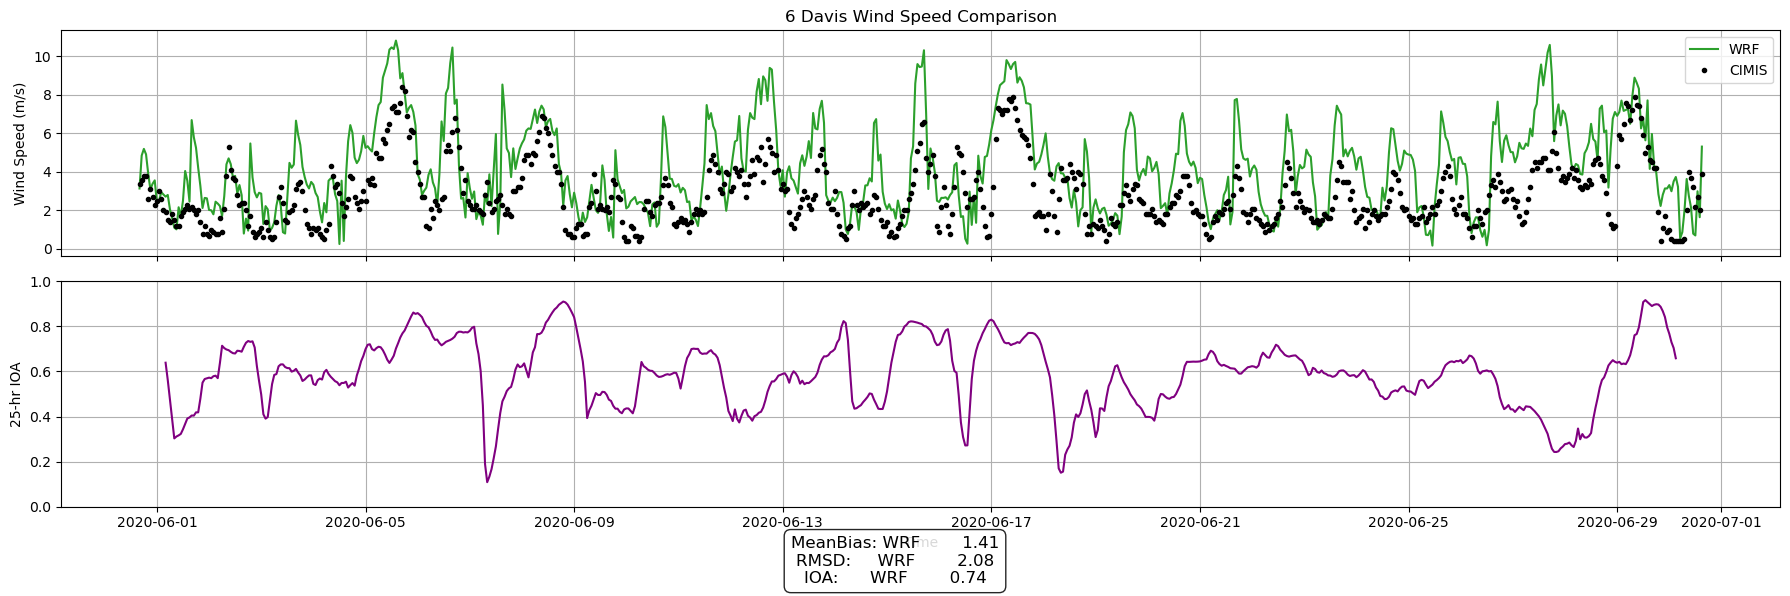

[[1.411513263028529], [2.0848286911054386], [0.7429296933944545]]


In [1]:
from GlobWRFFun import MonthGlob
from TestWRFFun import MonthTimeSeries
import pandas as pd

# ===============================
# USER SETTINGS
# ===============================
WINDOW = 25   # <-- change this (must be odd)

# ===============================
# WRF DATA
# ===============================
Var = "wspd10"
lat_point = 38.535694
lon_point = -121.77636

WRFFiles = ["/data/wto/WRFOUT/Sac_PBL2_MP8_RAD4_260120/wrfout_d01_2020-06-*"]

Time, Vals = MonthGlob(WRFFiles, Var, lat_point, lon_point)

wrf_time = []
wrf_vals = []

for t, w in zip(Time, Vals[0]):
    t_pst = pd.to_datetime(t) - pd.Timedelta(hours=8)
    wrf_time.append(t_pst)
    wrf_vals.append(w)

# ===============================
# CIMIS DATA
# ===============================
cimis_file = "/home/mpasillaspablo/CIMIS/6_Davis_hly2020.csv"

df = pd.read_csv(cimis_file)

stn_id = df["Stn Id"].iloc[0]
stn_name = df["Stn Name"].iloc[0]

# --- Fix hour formatting ---
hour = df["Hour (PST)"].astype(str).str.zfill(4)

midnight_mask = hour == "2400"
hour_clean = hour.replace("2400", "0000")

df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + hour_clean,
    format="%m/%d/%Y %H%M"
)

df.loc[midnight_mask, "Datetime"] += pd.Timedelta(days=1)

# --- Match WRF time range ---
start = pd.Timestamp("2020-05-31 16:00:00")
end   = pd.Timestamp("2020-06-30 15:00:00")

df = df[(df["Datetime"] >= start) & (df["Datetime"] <= end)]

cimis_time = df["Datetime"]
cimis_vals = df["Wind Speed (m/s)"]

# ===============================
# ALIGN DATA
# ===============================
min_len = min(len(cimis_vals), len(wrf_vals))

Time = list(cimis_time[:min_len])

Vals = [
    list(cimis_vals[:min_len]),  # observed (CIMIS)
    list(wrf_vals[:min_len])     # model (WRF)
]

Legend = ["CIMIS", "WRF"]

# ===============================
# PLOT + STATS
# ===============================
stats = MonthTimeSeries(
    Time,
    Vals,
    Title=f"{stn_id} {stn_name} Wind Speed Comparison",
    YLabel="Wind Speed (m/s)",
    Legend=Legend,
    Show=True,
    Window=WINDOW   # <-- passes your adjustable window
)

# ===============================
# OPTIONAL: PRINT STATS
# ===============================
mean_diffs, rmsds, ioas = stats



=== Running IOA (time, value) ===
2020-05-31 16:00:00 nan
2020-05-31 17:00:00 nan
2020-05-31 18:00:00 nan
2020-05-31 19:00:00 nan
2020-05-31 20:00:00 nan
2020-05-31 21:00:00 nan
2020-05-31 22:00:00 nan
2020-05-31 23:00:00 nan
2020-06-01 00:00:00 nan
2020-06-01 01:00:00 nan
2020-06-01 02:00:00 nan
2020-06-01 03:00:00 nan
2020-06-01 04:00:00 0.6386001127925659
2020-06-01 05:00:00 0.561685642021496
2020-06-01 06:00:00 0.47688631586750574
2020-06-01 07:00:00 0.3923135662168473
2020-06-01 08:00:00 0.30297486730338485
2020-06-01 09:00:00 0.3113622731381287
2020-06-01 10:00:00 0.31638087989452646
2020-06-01 11:00:00 0.32290473008364873
2020-06-01 12:00:00 0.34335125771643704
2020-06-01 13:00:00 0.3668394503197646
2020-06-01 14:00:00 0.3911329373345448
2020-06-01 15:00:00 0.39592079055222995
2020-06-01 16:00:00 0.4044840847275355
2020-06-01 17:00:00 0.4040121904515509
2020-06-01 18:00:00 0.4184471118172044
2020-06-01 19:00:00 0.4184717697308572
2020-06-01 20:00:00 0.4792895582080723
2020-06-0

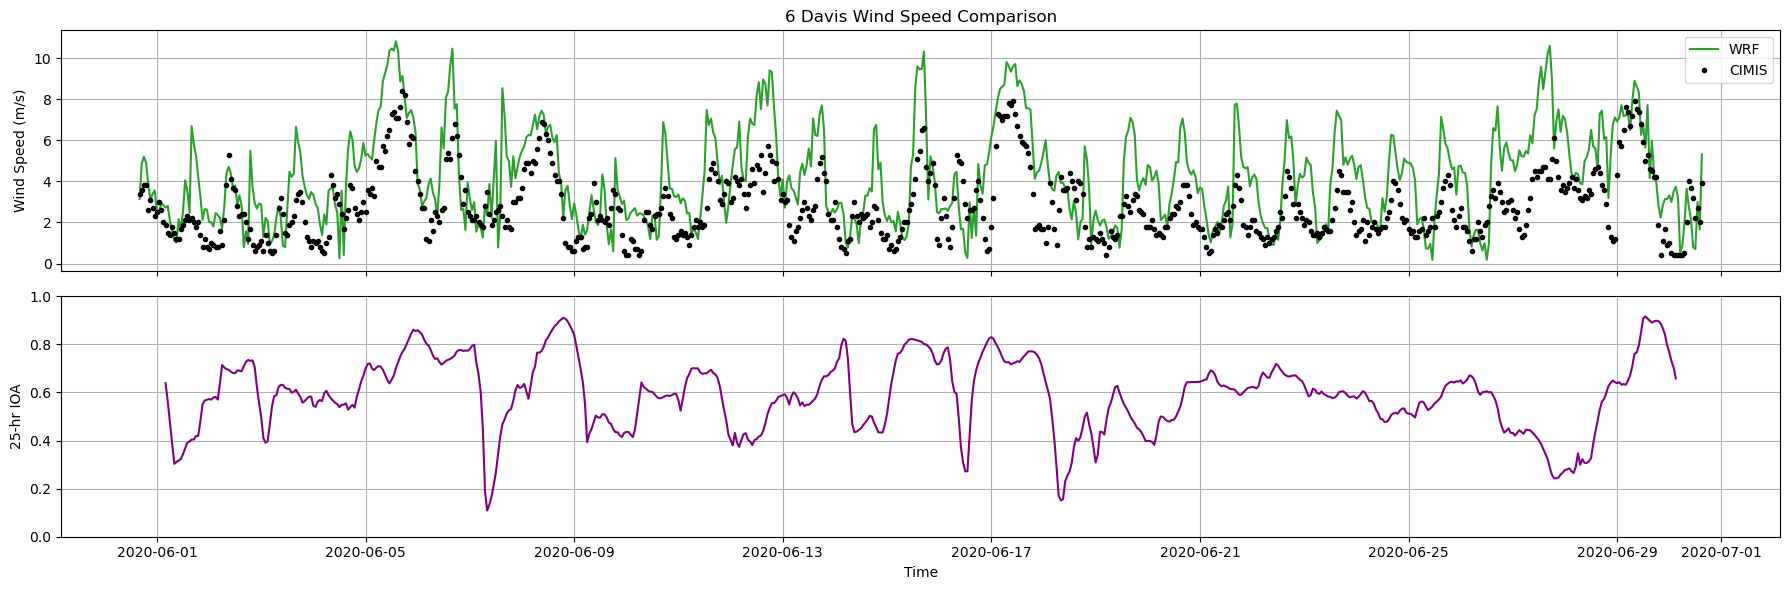

[[1.411513263028529], [2.0848286911054386], [0.7429296933944545]]


In [1]:
from GlobWRFFun import MonthGlob
from TestWRFFun import MonthTimeSeries
import pandas as pd

# ===============================
# USER SETTINGS
# ===============================
WINDOW = 25   # must be odd

# ===============================
# WRF DATA
# ===============================
Var = "wspd10"
lat_point = 38.535694
lon_point = -121.77636

WRFFiles = ["/data/wto/WRFOUT/Sac_PBL2_MP8_RAD4_260120/wrfout_d01_2020-06-*"]

Time, Vals = MonthGlob(WRFFiles, Var, lat_point, lon_point)

wrf_time = []
wrf_vals = []

for t, w in zip(Time, Vals[0]):
    t_pst = pd.to_datetime(t) - pd.Timedelta(hours=8)
    wrf_time.append(t_pst)
    wrf_vals.append(w)

# ===============================
# CIMIS DATA
# ===============================
cimis_file = "/home/mpasillaspablo/CIMIS/6_Davis_hly2020.csv"

df = pd.read_csv(cimis_file)

stn_id = df["Stn Id"].iloc[0]
stn_name = df["Stn Name"].iloc[0]

hour = df["Hour (PST)"].astype(str).str.zfill(4)

midnight_mask = hour == "2400"
hour_clean = hour.replace("2400", "0000")

df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + hour_clean,
    format="%m/%d/%Y %H%M"
)

df.loc[midnight_mask, "Datetime"] += pd.Timedelta(days=1)

start = pd.Timestamp("2020-05-31 16:00:00")
end   = pd.Timestamp("2020-06-30 15:00:00")

df = df[(df["Datetime"] >= start) & (df["Datetime"] <= end)]

cimis_time = df["Datetime"]
cimis_vals = df["Wind Speed (m/s)"]

# ===============================
# ALIGN DATA
# ===============================
min_len = min(len(cimis_vals), len(wrf_vals))

Time = list(cimis_time[:min_len])

Vals = [
    list(cimis_vals[:min_len]),  # observed
    list(wrf_vals[:min_len])     # model
]

Legend = ["CIMIS", "WRF"]

# ===============================
# PLOT + STATS
# ===============================
stats = MonthTimeSeries(
    Time,
    Vals,
    Title=f"{stn_id} {stn_name} Wind Speed Comparison",
    YLabel="Wind Speed (m/s)",
    Legend=Legend,
    Show=True,
    Window=WINDOW,
    PrintRunningIOA=True   # <-- toggle debugging here
)

# ===============================
# OUTPUT
# ===============================
mean_diffs, rmsds, ioas = stats